In [ ]:
#!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00


### Note
This notebook was executed in Google Colab.
Dataset files are not included in this repository.
Environment dependencies are listed in requirements.txt.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings("ignore")


In [ ]:
#train_df = pd.read_csv('/content/train_data.csv')
#test_df  = pd.read_csv('/content/test_data.csv')

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


Train shape: (72158, 24)
Test shape : (72158, 23)


In [7]:
TARGET = 'actual_time'


In [8]:
train_df.head()


,UID,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,actual_time
0,lWYYrbNEdf,2018-09-15 02:23:18.656742,thanos::sroute:9d8ed3f7-a8af-4393-ad7a-c57a720...,FTL,trip-153697819865649878,IND832109AAB,Jamshedpur_Central_I_3 (Jharkhand),IND834002AAB,Ranchi_Hub (Jharkhand),2018-09-15 02:23:18.656742,...,2018-09-15 04:45:23,158.807515,778.672716,1228.735753,2.782826,77.988686,20.793472,28.475783,3.292773,100.0
1,iNJcHQlPCm,2018-09-30 15:07:48.971326,thanos::sroute:b9142a73-d68f-46ec-9afc-d145479...,FTL,trip-153832006897106333,IND422011AAD,Nashik_TgrniaRD_I (Maharashtra),IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),2018-09-30 22:38:13.903069,...,2018-10-01 05:38:30,81.388109,227.479029,NaN,3.625248,68.517914,18.787231,34.612259,4.277350,61.0
2,U6N0M43qwR,2018-09-23 22:15:46.635975,thanos::sroute:883e99fa-50a3-40e0-a2e2-9b12ed6...,FTL,trip-153774094663572416,IND845305AAA,Raxaul_KairiyaT_D (Bihar),NaN,Muzaffrpur_Bbganj_I (Bihar),2018-09-24 03:56:37.016232,...,2018-09-24 09:21:30,134.486898,400.072069,1188.943158,4.415969,70.475386,24.371978,29.867950,5.322072,69.0
3,RrJUneuYNj,2018-09-21 05:11:44.833176,thanos::sroute:96a80600-40e1-436b-9161-fa68f9e...,FTL,trip-153750670483274503,IND842001AAA,Muzaffrpur_Bbganj_I (Bihar),IND854326AAB,Purnia_Central_H_2 (Bihar),2018-09-22 10:08:32.593022,...,2018-09-22 14:09:17,262.866674,510.123878,999.421258,2.946647,101.876844,19.588977,27.794019,4.265799,300.0
4,7QLdD7iRC9,2018-09-18 01:10:49.936747,thanos::sroute:b43ec86d-59c1-452c-b4a9-807d357...,FTL,trip-153723305402762987,IND411033AAA,Pune_Tathawde_H (Maharashtra),IND501359AAE,Hyderabad_Shamshbd_H (Telangana),2018-09-18 01:10:49.936747,...,2018-09-18 12:14:05,379.389280,NaN,NaN,1.998790,46.571301,22.671495,26.971844,3.553652,286.0


In [9]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72158 entries, 0 to 72157
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   UID                             72158 non-null  object 
 1   trip_creation_time              68643 non-null  object 
 2   route_schedule_uuid             69263 non-null  object 
 3   route_type                      72158 non-null  object 
 4   trip_uuid                       72158 non-null  object 
 5   source_center                   72158 non-null  object 
 6   source_name                     72158 non-null  object 
 7   destination_center              71355 non-null  object 
 8   destination_name                72158 non-null  object 
 9   od_start_time                   72158 non-null  object 
 10  od_end_time                     71438 non-null  object 
 11  start_scan_to_end_scan          72158 non-null  float64
 12  is_cutoff                       

In [10]:
datetime_cols = [
    'trip_creation_time',
    'od_start_time',
    'od_end_time',
    'cutoff_timestamp'
]

for col in datetime_cols:
    train_df[col] = pd.to_datetime(train_df[col], errors='coerce')
    test_df[col]  = pd.to_datetime(test_df[col], errors='coerce')


In [11]:
def time_features(df):
    df['trip_hour'] = df['trip_creation_time'].dt.hour
    df['trip_weekday'] = df['trip_creation_time'].dt.weekday
    df['is_weekend'] = (df['trip_weekday'] >= 5).astype(int)

    df['od_duration_min'] = (
        (df['od_end_time'] - df['od_start_time'])
        .dt.total_seconds() / 60
    )

    # ---- SAFE distance interaction ----
    dist_col = None
    for c in ['distance', 'osrm_distance', 'distance_osrm', 'total_distance']:
        if c in df.columns:
            dist_col = c
            break

    if dist_col is not None:
        df['hour_x_distance'] = df['trip_hour'] * df[dist_col]
    else:
        df['hour_x_distance'] = 0

    # ---- SAFE OSRM interaction ----
    if 'osrm_time' in df.columns:
        df['hour_x_osrm'] = df['trip_hour'] * df['osrm_time']
    else:
        df['hour_x_osrm'] = 0

    return df

train_df = time_features(train_df)
test_df  = time_features(test_df)


In [12]:
drop_cols = [
    'UID',
    'trip_uuid',
    'route_schedule_uuid',
    'source_name',
    'destination_name',
    'trip_creation_time',
    'od_start_time',
    'od_end_time',
    'cutoff_timestamp'
]

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)


In [13]:
num_cols = train_df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    train_df[col].fillna(train_df[col].median(), inplace=True)
    if col in test_df.columns:
        test_df[col].fillna(train_df[col].median(), inplace=True)


In [14]:
train_df['log_actual_time'] = np.log1p(train_df[TARGET])


In [15]:
X = train_df.drop(columns=[TARGET, 'log_actual_time'])
y = train_df['log_actual_time']

# force same column order
test_df = test_df[X.columns]


In [16]:
cat_cols = [
    col for col in X.columns
    if X[col].dtype == 'object' or test_df[col].dtype == 'object'
]

for col in cat_cols:
    X[col] = X[col].fillna("missing").astype(str)
    test_df[col] = test_df[col].fillna("missing").astype(str)

cat_features = [X.columns.get_loc(col) for col in cat_cols]


In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [18]:
X_train_base = X_train.copy()
X_val_base   = X_val.copy()

for col in cat_cols:
    X_train_base[col] = X_train_base[col].astype('category').cat.codes
    X_val_base[col]   = X_val_base[col].astype('category').cat.codes


In [19]:
lr = LinearRegression()
lr.fit(X_train_base, y_train)

lr_preds_log = lr.predict(X_val_base)
lr_preds = np.expm1(lr_preds_log)
y_val_true = np.expm1(y_val)

lr_mae  = mean_absolute_error(y_val_true, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_val_true, lr_preds))

print("Linear Regression MAE :", lr_mae)
print("Linear Regression RMSE:", lr_rmse)


Linear Regression MAE : 283.04707222654434
Linear Regression RMSE: 3302.1674790938805


In [20]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=16,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_base, y_train)

rf_preds_log = rf.predict(X_val_base)
rf_preds = np.expm1(rf_preds_log)

rf_mae  = mean_absolute_error(y_val_true, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_val_true, rf_preds))

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)


Random Forest MAE : 36.36342071059219
Random Forest RMSE: 74.29773466106242


In [21]:
cat_model = CatBoostRegressor(
    loss_function='MAE',
    depth=8,
    learning_rate=0.05,
    iterations=500,
    l2_leaf_reg=5,
    subsample=0.8,
    random_strength=1,
    bagging_temperature=0.5,
    random_state=42,
    verbose=100
)


In [22]:
cat_model.fit(
    X_train, y_train,
    cat_features=cat_features
)


0:	learn: 1.1224916	total: 143ms	remaining: 1m 11s
100:	learn: 0.1390746	total: 7.26s	remaining: 28.7s
200:	learn: 0.1217111	total: 15.4s	remaining: 23s
300:	learn: 0.1141072	total: 23.4s	remaining: 15.4s
400:	learn: 0.1089219	total: 31.2s	remaining: 7.71s
499:	learn: 0.1051040	total: 39.5s	remaining: 0us


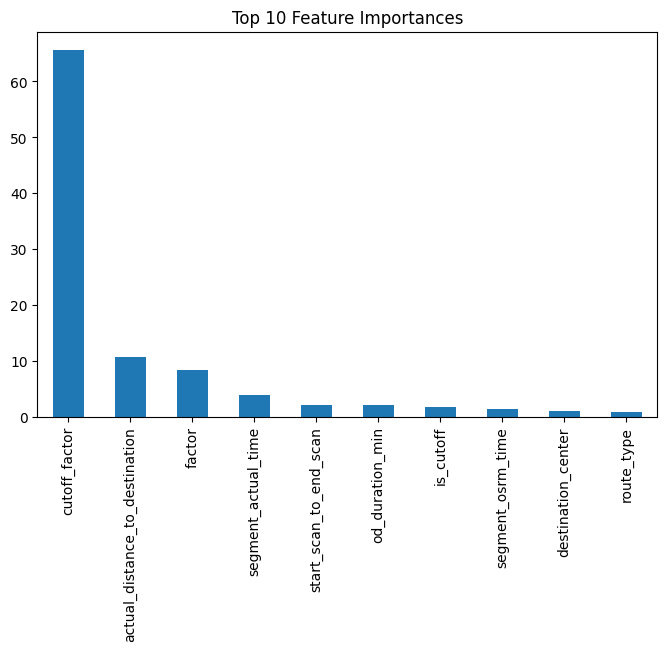

In [23]:
feat_imp = pd.Series(
    cat_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feat_imp.head(10)
plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='bar')
plt.title("Top 10 Feature Importances")
plt.show()


In [24]:
cat_preds_log = cat_model.predict(X_val)
cat_preds = np.expm1(cat_preds_log)

cat_mae  = mean_absolute_error(y_val_true, cat_preds)
cat_rmse = np.sqrt(mean_squared_error(y_val_true, cat_preds))

print("CatBoost MAE :", cat_mae)
print("CatBoost RMSE:", cat_rmse)


CatBoost MAE : 29.018926303727767
CatBoost RMSE: 58.81166029786504


In [25]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "CatBoost"],
    "MAE": [lr_mae, rf_mae, cat_mae],
    "RMSE": [lr_rmse, rf_rmse, cat_rmse]
})

comparison


,Model,MAE,RMSE
0,Linear Regression,283.047072,3302.167479
1,Random Forest,36.363421,74.297735
2,CatBoost,29.018926,58.811660


In [26]:
cat_model.fit(
    X, y,
    cat_features=cat_features
)


0:	learn: 1.1222052	total: 114ms	remaining: 56.8s
100:	learn: 0.1376684	total: 9.45s	remaining: 37.3s
200:	learn: 0.1213571	total: 17.7s	remaining: 26.3s
300:	learn: 0.1133689	total: 27s	remaining: 17.9s
400:	learn: 0.1081736	total: 36.5s	remaining: 9s
499:	learn: 0.1040960	total: 44.2s	remaining: 0us


In [27]:
from catboost import Pool

test_pool = Pool(
    data=test_df,
    cat_features=cat_features
)

test_preds_log = cat_model.predict(test_pool)
test_predictions = np.expm1(test_preds_log)


In [28]:
# Convert validation target back to original scale
y_val_actual = np.expm1(y_val)

# Create comparison DataFrame
val_output = pd.DataFrame({
    'Actual_time': y_val_actual.values,
    'Predicted_time': cat_preds
})

val_output.head(20)


,Actual_time,Predicted_time
0,30.0,34.644947
1,44.0,55.441132
2,54.0,65.087380
3,63.0,69.885851
4,30.0,35.231650
5,179.0,163.290890
6,23.0,30.850694
7,657.0,619.918792
8,138.0,83.409125
9,120.0,101.033056


In [29]:
output = pd.DataFrame({
    'UID': test_df.index,
    'predicted_delivery_time': test_predictions
})
output.head()

,UID,predicted_delivery_time
0,0,34.081863
1,1,56.436085
2,2,11.067644
3,3,51.378201
4,4,30.197203


In [30]:
cat_model.save_model("catboost_model.cbm")


In [33]:
X.to_json("feature_schema.json", orient="columns")

In [ ]:
!jupyter nbconvert --to script your_notebook_name.ipynb




**OVERFITTED MODEL **

In [31]:
# import numpy as np
# import pandas as pd
# import os

# from datetime import datetime

# # plotting
# import matplotlib.pyplot as plt
# import seaborn as sns

# # sklearn
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# # stats
# from scipy import stats

# # model
# !pip install catboost
# from catboost import CatBoostRegressor

# pd.options.display.max_columns = 250
# pd.options.display.max_rows = 250


In [32]:
# df  = pd.read_csv('/content/train_data.csv')
# df1 = pd.read_csv('/content/test_data.csv')

# print(df.shape, df1.shape)


(72158, 24) (72158, 23)


In [33]:
# nullcols = [col for col in df.columns if df[col].isnull().sum() > 120000]

# df.drop(nullcols, axis=1, inplace=True)
# df1.drop(nullcols, axis=1, inplace=True)


In [34]:
# df.drop('UID', axis=1, inplace=True)
# df1.drop('UID', axis=1, inplace=True)


In [35]:
# for col in ['od_start_time','od_end_time','trip_creation_time']:
#     df[col + '_1']  = df[col]
#     df1[col + '_1'] = df1[col]


In [36]:
# df['od_start_time'] = pd.to_datetime(df['od_start_time'])
# df['od_end_time']   = pd.to_datetime(df['od_end_time'])

# df1['od_start_time'] = pd.to_datetime(df1['od_start_time'])
# df1['od_end_time']   = pd.to_datetime(df1['od_end_time'])


In [37]:
# df['segment_key'] = df['trip_uuid'] + df['source_center'] + df['destination_center']
# df1['segment_key'] = df1['trip_uuid'] + df1['source_center'] + df1['destination_center']

# segment_cols = ['segment_actual_time', 'segment_osrm_distance', 'segment_osrm_time']

# for col in segment_cols:
#     df[col + '_sum']  = df.groupby('segment_key')[col].cumsum()
#     df1[col + '_sum'] = df1.groupby('segment_key')[col].cumsum()


In [38]:
# df['od_time_diff_hour']  = (df['od_end_time'] - df['od_start_time']).dt.total_seconds() / 60
# df1['od_time_diff_hour'] = (df1['od_end_time'] - df1['od_start_time']).dt.total_seconds() / 60


In [39]:
# def place2state(x):
#     if isinstance(x, str) and '(' in x:
#         return x.split('(')[1][:-1]
#     return None

# def place2city(x):
#     if isinstance(x, str) and ' (' in x:
#         return x.split(' (')[0].split('_')[0]
#     return None

# def place2city_place(x):
#     if isinstance(x, str) and ' (' in x:
#         return x.split(' (')[0]
#     return None

# def place2code(x):
#     if isinstance(x, str) and ' (' in x:
#         return x.split(' (')[0].split('_')[-1]
#     return None


In [40]:
# for d in [df, df1]:
#     d['destination_state'] = d['destination_name'].apply(place2state)
#     d['destination_city']  = d['destination_name'].apply(place2city)
#     d['destination_place'] = d['destination_name'].apply(place2city_place)
#     d['destination_code']  = d['destination_name'].apply(place2code)


In [43]:
# df['trip_creation_time']  = pd.to_datetime(df['trip_creation_time'])
# df1['trip_creation_time'] = pd.to_datetime(df1['trip_creation_time'])

# for d in [df, df1]:
#     d['trip_year'] = d['trip_creation_time'].dt.year
#     d['trip_month'] = d['trip_creation_time'].dt.month
#     d['trip_hour'] = d['trip_creation_time'].dt.hour
#     d['trip_day'] = d['trip_creation_time'].dt.day
#     d['trip_week'] = (
#     d['trip_creation_time']
#     .dt.isocalendar()
#     .week
#     .fillna(0)
#     .astype(int)
# )

#     d['trip_dayofweek'] = d['trip_creation_time'].dt.dayofweek


In [44]:
# df['route_type']  = df['route_type'].map({'FTL':0, 'Carting':1})
# df1['route_type'] = df1['route_type'].map({'FTL':0, 'Carting':1})


In [45]:
# num_cols = [
#     'start_scan_to_end_scan','actual_distance_to_destination',
#     'segment_actual_time_sum','osrm_time','osrm_distance',
#     'segment_osrm_distance_sum','segment_osrm_time_sum',
#     'od_time_diff_hour'
# ]

# scaler = StandardScaler()
# df[num_cols]  = scaler.fit_transform(df[num_cols])
# df1[num_cols] = scaler.transform(df1[num_cols])


In [47]:
# from sklearn.preprocessing import LabelEncoder

# for col in df.columns:
#     if df[col].dtype == 'object' or df[col].dtype == 'bool':

#         # combine train + test
#         combined = pd.concat(
#             [df[col].astype(str), df1[col].astype(str)],
#             axis=0
#         )

#         le = LabelEncoder()
#         le.fit(combined)

#         df[col]  = le.transform(df[col].astype(str))
#         df1[col] = le.transform(df1[col].astype(str))


In [48]:
# drop_time_cols = ['trip_week','trip_creation_time','od_start_time','od_end_time']
# df.drop(drop_time_cols, axis=1, inplace=True)
# df1.drop(drop_time_cols, axis=1, inplace=True)


In [50]:
# # Numeric columns
# num_cols = df1.select_dtypes(include=[np.number]).columns
# df[num_cols]  = df[num_cols].fillna(df[num_cols].mean())
# df1[num_cols] = df1[num_cols].fillna(df1[num_cols].mean())

# # Non-numeric columns (object / bool)
# cat_cols = df1.select_dtypes(exclude=[np.number]).columns
# df[cat_cols]  = df[cat_cols].fillna("missing")
# df1[cat_cols] = df1[cat_cols].fillna("missing")


In [53]:
# def outlier_thresholds(dataframe, variable):
#     q1 = dataframe[variable].quantile(0.01)
#     q3 = dataframe[variable].quantile(0.99)
#     iqr = q3 - q1
#     return q1 - 1.5 * iqr, q3 + 1.5 * iqr

# def replace_with_thresholds(dataframe, variable):
#     low, high = outlier_thresholds(dataframe, variable)
#     dataframe.loc[dataframe[variable] < low, variable] = low
#     dataframe.loc[dataframe[variable] > high, variable] = high
# # numeric columns common in BOTH train & test
# num_cols = [
#     col for col in df.columns
#     if (
#         col in df1.columns
#         and pd.api.types.is_numeric_dtype(df[col])
#         and pd.api.types.is_numeric_dtype(df1[col])
#     )
# ]

# print("Outlier treatment on columns:", num_cols)

# for col in num_cols:
#     replace_with_thresholds(df, col)
#     replace_with_thresholds(df1, col)


Outlier treatment on columns: ['route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'od_start_time_1', 'od_end_time_1', 'trip_creation_time_1', 'segment_key', 'segment_actual_time_sum', 'segment_osrm_distance_sum', 'segment_osrm_time_sum', 'od_time_diff_hour', 'destination_state', 'destination_city', 'destination_place', 'destination_code', 'trip_year', 'trip_month', 'trip_hour', 'trip_day', 'trip_dayofweek']


In [55]:
# X = df.drop('actual_time', axis=1)
# y = df['actual_time']

# from sklearn.preprocessing import StandardScaler

# # Identify numeric columns COMMON in train & test
# num_cols = [
#     col for col in X.columns
#     if (
#         col in df1.columns
#         and pd.api.types.is_numeric_dtype(X[col])
#         and pd.api.types.is_numeric_dtype(df1[col])
#     )
# ]

# print("Scaling numeric columns:", num_cols)

# scaler = StandardScaler()

# # Fit on TRAIN only
# X[num_cols] = scaler.fit_transform(X[num_cols])

# # Transform TEST using same scaler
# df1[num_cols] = scaler.transform(df1[num_cols])


Scaling numeric columns: ['route_type', 'trip_uuid', 'source_center', 'source_name', 'destination_center', 'destination_name', 'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'actual_distance_to_destination', 'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor', 'od_start_time_1', 'od_end_time_1', 'trip_creation_time_1', 'segment_key', 'segment_actual_time_sum', 'segment_osrm_distance_sum', 'segment_osrm_time_sum', 'od_time_diff_hour', 'destination_state', 'destination_city', 'destination_place', 'destination_code', 'trip_year', 'trip_month', 'trip_hour', 'trip_day', 'trip_dayofweek']


In [56]:
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y,
#     test_size=0.001,
#     random_state=42
# )


In [57]:
# model = CatBoostRegressor(
#     n_estimators=20000,
#     learning_rate=0.075,
#     max_depth=9,
#     verbose=200
# )

# model.fit(X_train, y_train)


0:	learn: 558.4915856	total: 123ms	remaining: 40m 52s
200:	learn: 44.5227567	total: 22.9s	remaining: 37m 38s
400:	learn: 34.6740970	total: 38.3s	remaining: 31m 12s
600:	learn: 29.4683178	total: 50.8s	remaining: 27m 19s
800:	learn: 25.8328655	total: 1m 3s	remaining: 25m 19s
1000:	learn: 23.1002001	total: 1m 16s	remaining: 24m 12s
1200:	learn: 21.0343353	total: 1m 29s	remaining: 23m 22s
1400:	learn: 19.2901902	total: 1m 42s	remaining: 22m 45s
1600:	learn: 17.8698351	total: 1m 56s	remaining: 22m 15s
1800:	learn: 16.5978113	total: 2m 9s	remaining: 21m 46s
2000:	learn: 15.4708703	total: 2m 22s	remaining: 21m 18s
2200:	learn: 14.5235964	total: 2m 34s	remaining: 20m 53s
2400:	learn: 13.6740278	total: 2m 47s	remaining: 20m 30s
2600:	learn: 12.9020783	total: 3m 1s	remaining: 20m 11s
2800:	learn: 12.1957923	total: 3m 14s	remaining: 19m 54s
3000:	learn: 11.5446467	total: 3m 27s	remaining: 19m 34s
3200:	learn: 10.9583708	total: 3m 40s	remaining: 19m 15s
3400:	learn: 10.4223199	total: 3m 53s	remain

In [58]:
# y_pred = model.predict(X_val)

# mae  = mean_absolute_error(y_val, y_pred)
# rmse = np.sqrt(mean_squared_error(y_val, y_pred))
# r2   = r2_score(y_val, y_pred)

# print("MAE :", mae)
# print("RMSE:", rmse)
# print("R2  :", r2)


MAE : 15.983810722376008
RMSE: 23.63892267837171
R2  : 0.9978641161567311


In [77]:
# comparison_df = pd.DataFrame({
#     'Actual': y_val.values.flatten(),
#     'Predicted': y_pred.flatten()
# })




In [78]:
# print(comparison_df.head(50))

    Actual    Predicted
0     30.0    25.569847
1     44.0    59.855985
2     54.0    62.761546
3     63.0    58.083531
4     30.0    38.519609
5    179.0   152.891013
6     23.0    28.491698
7    657.0   659.985301
8    138.0   110.916802
9    120.0   125.085395
10    38.0    33.502658
11   298.0   301.282299
12   138.0   180.493149
13    73.0    81.479899
14    32.0    25.044666
15    44.0    39.419259
16    34.0    28.796371
17    96.0   112.519841
18   504.0   481.938650
19   134.0   131.814979
20    24.0    27.809796
21    76.0    65.387403
22   217.0   194.909551
23   174.0   258.325793
24    55.0    53.536562
25    83.0    88.898444
26    56.0    72.628636
27    43.0    47.148675
28    32.0    28.027216
29    81.0    84.191742
30   208.0   156.720368
31  1374.0  1319.093998
32    41.0    40.959516
33   553.0   559.401225
34   540.0   537.781457
35   398.0   367.991049
36  1260.0  1226.231668
37   239.0   215.604143
38    54.0    52.178456
39  1494.0  1486.313749
40   446.0   452